# 1. Tensor Manipulations & Reshaping

In [1]:
import tensorflow as tf

# 1. Create a random tensor of shape (4, 6)
tensor = tf.random.normal((4, 6))

print("Original Tensor:")
print(tensor)

# 2. Find the rank and shape
print("\nOriginal Rank:", tf.rank(tensor).numpy())
print("Original Shape:", tensor.shape)

# 3. Reshape the tensor into (2, 3, 4)
reshaped_tensor = tf.reshape(tensor, (2, 3, 4))

print("\nAfter Reshaping:")
print("Rank:", tf.rank(reshaped_tensor).numpy())
print("Shape:", reshaped_tensor.shape)

# Transpose the tensor into (3, 2, 4)
transposed_tensor = tf.transpose(reshaped_tensor, perm=[1, 0, 2])

print("\nAfter Transposing:")
print("Rank:", tf.rank(transposed_tensor).numpy())
print("Shape:", transposed_tensor.shape)

# 4. Create a smaller tensor of shape (1, 4)
small_tensor = tf.random.normal((1, 4))

# Add the tensors using broadcasting
result = transposed_tensor + small_tensor

print("\nSmall Tensor:")
print(small_tensor)

print("\nAfter Broadcasting and Addition:")
print("Rank:", tf.rank(result).numpy())
print("Shape:", result.shape)
print(result)

Original Tensor:
tf.Tensor(
[[-0.11746258 -1.3279206  -0.09859199 -0.77668947  0.18092768 -0.8166478 ]
 [-0.65150845  1.4884194   1.0005287  -0.0946685   0.8520704   0.29209194]
 [-2.795302   -1.3748766  -0.52797145 -0.01804259 -0.14439236 -0.3984584 ]
 [-1.5942651  -0.32950413 -1.0795958   1.1767554   1.2809439  -0.49459177]], shape=(4, 6), dtype=float32)

Original Rank: 2
Original Shape: (4, 6)

After Reshaping:
Rank: 3
Shape: (2, 3, 4)

After Transposing:
Rank: 3
Shape: (3, 2, 4)

Small Tensor:
tf.Tensor([[-0.28479496 -0.12548877 -0.7142776   2.1066384 ]], shape=(1, 4), dtype=float32)

After Broadcasting and Addition:
Rank: 3
Shape: (3, 2, 4)
tf.Tensor(
[[[-0.40225753 -1.4534093  -0.8128696   1.3299489 ]
  [-3.080097   -1.5003654  -1.242249    2.0885959 ]]

 [[-0.10386728 -0.9421366  -1.3657861   3.595058  ]
  [-0.4291873  -0.5239472  -2.3085427   1.7771343 ]]

 [[ 0.71573377 -0.22015727  0.13779277  2.3987303 ]
  [-1.3643907   1.0512667   0.56666625  1.6120467 ]]], shape=(3, 2, 4),

Broadcasting allows TensorFlow to automatically expand a smaller tensor when its dimensions are compatible with a larger tensor. TensorFlow compares the dimensions from right to left. Dimensions are compatible when they are equal or when one of them is 1. In this example, (1,4) is compatible with (3,2,4), so the smaller tensor is broadcast across the first two dimensions and can be added to the larger tensor. The result has shape (3,2,4).

# 2. Loss Functions & Hyperparameter Tuning

Original Prediction: [[0.7 0.2 0.1]]
Modified Prediction: [[0.8 0.1 0.1]]

Original Prediction Losses:
MSE Loss: 0.04666667
Categorical Cross-Entropy Loss: 0.35667497

Modified Prediction Losses:
MSE Loss: 0.02
Categorical Cross-Entropy Loss: 0.22314353


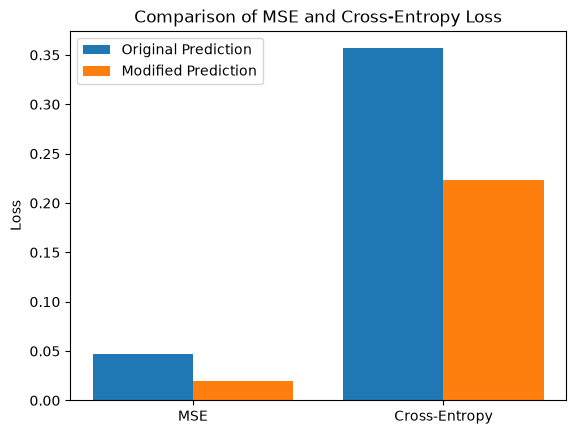

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define true values and predictions
y_true = tf.constant([[1.0, 0.0, 0.0]])

# Original prediction
y_pred1 = tf.constant([[0.7, 0.2, 0.1]])

# Slightly modified prediction
y_pred2 = tf.constant([[0.8, 0.1, 0.1]])

# 2. Define loss functions (MSE and CCE)
mse = tf.keras.losses.MeanSquaredError()
cce = tf.keras.losses.CategoricalCrossentropy()

# Calculate losses for the original prediction
mse_loss1 = mse(y_true, y_pred1).numpy()
cce_loss1 = cce(y_true, y_pred1).numpy()

# Calculate losses for the modified prediction
mse_loss2 = mse(y_true, y_pred2).numpy()
cce_loss2 = cce(y_true, y_pred2).numpy()

# 3. Print loss values
print("Original Prediction:", y_pred1.numpy())
print("Modified Prediction:", y_pred2.numpy())

print("\nOriginal Prediction Losses:")
print("MSE Loss:", mse_loss1)
print("Categorical Cross-Entropy Loss:", cce_loss1)

print("\nModified Prediction Losses:")
print("MSE Loss:", mse_loss2)
print("Categorical Cross-Entropy Loss:", cce_loss2)

# 4. Plot loss function values using Matplotlib
labels = ["MSE", "Cross-Entropy"]

original_losses = [mse_loss1, cce_loss1]
modified_losses = [mse_loss2, cce_loss2]

x = range(len(labels))

plt.bar(x, original_losses, width=0.4, label="Original Prediction")
plt.bar([i + 0.4 for i in x], modified_losses, width=0.4, label="Modified Prediction")

plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel("Loss")
plt.title("Comparison of MSE and Cross-Entropy Loss")
plt.legend()
plt.show()

The experiment compares Mean Squared Error (MSE) and Categorical Cross-Entropy (CCE) using different model predictions. The true label is `[1, 0, 0]`. The original prediction is `[0.7, 0.2, 0.1]`, while the modified prediction is `[0.8, 0.1, 0.1]`.

When the prediction becomes closer to the true label, both loss values decrease. The MSE decreases from approximately 0.0467 to 0.02, while the Categorical Cross-Entropy decreases from approximately 0.3567 to 0.2231. This shows that a lower loss indicates that the model prediction is closer to the true values. MSE measures the squared difference between the true values and predictions, while Categorical Cross-Entropy measures how well the predicted probabilities match the correct class.

# 3. Train a Model with Different Optimizers

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)

Training model with Adam...


C:\Windows\System32\tensorflow_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9295 - loss: 0.2345 - val_accuracy: 0.9578 - val_loss: 0.1449
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9646 - loss: 0.1142 - val_accuracy: 0.9670 - val_loss: 0.1096
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9727 - loss: 0.0898 - val_accuracy: 0.9682 - val_loss: 0.1181
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9770 - loss: 0.0733 - val_accuracy: 0.9693 - val_loss: 0.1114
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0652 - val_accuracy: 0.9717 - val_loss: 0.1276
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9813 - loss: 0.0613 - val_accuracy: 0.9683 - val_loss: 0.1501
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9814 - loss: 0.0616 - val_accuracy: 0.9702 - val_loss: 0.1459
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9831 - loss: 0.0581 - val_accuracy: 0.

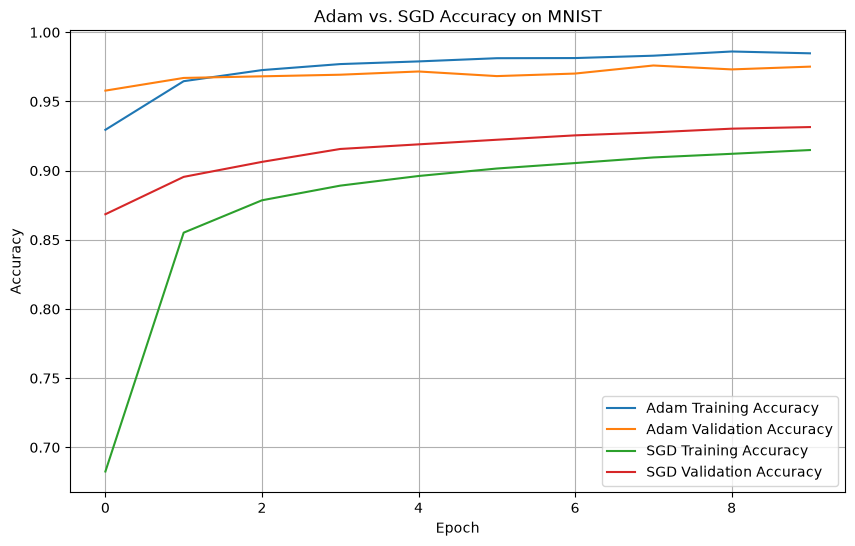


Final Validation Accuracy:
Adam: 0.9751666784286499
SGD: 0.9315000176429749


In [3]:
# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# 2. Create a model-building function
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model

# Create the Adam model
adam_model = create_model()

adam_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Create the SGD model
sgd_model = create_model()

sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Adam model
print("\nTraining model with Adam...")

adam_history = adam_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Train the SGD model
print("\nTraining model with SGD...")

sgd_history = sgd_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 3. Compare training and validation accuracy trends
plt.figure(figsize=(10, 6))

plt.plot(
    adam_history.history["accuracy"],
    label="Adam Training Accuracy"
)

plt.plot(
    adam_history.history["val_accuracy"],
    label="Adam Validation Accuracy"
)

plt.plot(
    sgd_history.history["accuracy"],
    label="SGD Training Accuracy"
)

plt.plot(
    sgd_history.history["val_accuracy"],
    label="SGD Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam vs. SGD Accuracy on MNIST")
plt.legend()
plt.grid(True)

plt.show()


# Print final validation accuracy
print("\nFinal Validation Accuracy:")
print("Adam:", adam_history.history["val_accuracy"][-1])
print("SGD:", sgd_history.history["val_accuracy"][-1])

The experiment compares the performance of Adam and SGD optimizers on the MNIST dataset. Both models use the same neural network architecture, training data, batch size, and number of epochs. The only major difference is the optimizer.

The accuracy plots show the training and validation accuracy trends for both optimizers. Adam generally reaches a high accuracy faster than SGD, while SGD improves more gradually. The validation accuracy follows a similar trend to the training accuracy. This experiment shows that the choice of optimizer can affect the speed and performance of neural network training.

# 4. Train a Neural Network and Log to TensorBoard

In [4]:
import tensorflow as tf
import datetime

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# 2. Create a simple neural network model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Create TensorBoard log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# 3. Train the model for 5 epochs
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    callbacks=[tensorboard_callback],
    verbose=1
)

print("TensorBoard logs saved to:", log_dir)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8942 - loss: 0.3783 - val_accuracy: 0.9553 - val_loss: 0.1712
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9493 - loss: 0.1763 - val_accuracy: 0.9675 - val_loss: 0.1247
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9630 - loss: 0.1275 - val_accuracy: 0.9732 - val_loss: 0.1034
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9712 - loss: 0.0990 - val_accuracy: 0.9720 - val_loss: 0.0974
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9767 - loss: 0.0807 - val_accuracy: 0.9775 - val_loss: 0.0842
TensorBoard logs saved to: logs/fit/20260908-001722


In [5]:
# Load the TensorBoard extension in Jupyter Notebook
%load_ext tensorboard
# Launch TensorBoard and display the logs from the 5-epoch experiment
%tensorboard --logdir logs/fit/20260908-001722

# 4.1-1

The training accuracy increased steadily from 89.42% in the first epoch to 97.67% in the fifth epoch. The validation accuracy also increased from 95.53% to 97.75%. Both curves show an improving trend, and the training and validation accuracy remain close by the end of training. This indicates that the model is learning the MNIST dataset effectively and generalizing well to the validation data.


# 4.1-2

TensorBoard can be used to detect overfitting by comparing the training and validation accuracy and loss curves. Overfitting may occur when training accuracy continues to increase while validation accuracy stops improving or decreases. Similarly, if training loss decreases while validation loss starts to increase, this is a strong sign of overfitting. In this experiment, both training and validation accuracy increased, while both training and validation loss decreased. Therefore, there is no clear evidence of overfitting after five epochs.


In [6]:
# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


# 2. Create the same neural network model
model_10 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


# Compile the model
model_10.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Create a NEW TensorBoard log directory
log_dir_10 = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback_10 = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir_10,
    histogram_freq=1
)


# 3. Train the model for 10 epochs
history_10 = model_10.fit(
    x_train,
    y_train,
    epochs=10,             
    batch_size=128,
    validation_split=0.1,
    callbacks=[tensorboard_callback_10],
    verbose=1
)


print("TensorBoard logs saved to:", log_dir_10)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8970 - loss: 0.3753 - val_accuracy: 0.9545 - val_loss: 0.1731
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9493 - loss: 0.1776 - val_accuracy: 0.9662 - val_loss: 0.1285
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9640 - loss: 0.1268 - val_accuracy: 0.9690 - val_loss: 0.1045
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9718 - loss: 0.0988 - val_accuracy: 0.9738 - val_loss: 0.0946
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9765 - loss: 0.0795 - val_accuracy: 0.9753 - val_loss: 0.0870
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9813 - loss: 0.0654 - val_accuracy: 0.9770 - val_loss: 0.0795
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0543 - val_accuracy: 0.9763 - val_loss: 0.0801
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━

In [7]:
# Load the TensorBoard extension in Jupyter Notebook
%load_ext tensorboard
# Launch TensorBoard and display the logs from the 10-epoch experiment    
%tensorboard --logdir logs/fit/20260908-001837

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


# 4.1-3

When the number of epochs is increased from 5 to 10, the model has more opportunities to learn from the training data. In my experiment, the training accuracy increased from 89.70% in the first epoch to 99.10% in the tenth epoch, while the training loss decreased from 0.3753 to 0.0331. The validation accuracy also improved overall, reaching 97.78% at the tenth epoch, although it fluctuated slightly after some epochs.

The validation loss decreased from 0.1731 in the first epoch to 0.0742 in the tenth epoch. The validation loss reached its lowest value of 0.0732 at epoch 9 and then increased slightly to 0.0742 at epoch 10. (it fluctuated slightly after some epochs.) This slight increase, together with the continued improvement in training accuracy, may indicate the beginning of overfitting.

Overall, increasing the number of epochs improved the model's performance, but training for too many epochs may eventually lead to overfitting.